# Sentiment Tables
## Completed by William Brannock (svv8fs)

This notebook handles the sentiment analysis tasks for the Final Project. For this one I used this notebook as a guide: https://www.kaggle.com/code/ontoligent/uva-ds-5001-m10-sentiment-analysis-of-novels

# Set Up

## Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Config

In [2]:
data_home = "."
output_dir = "output"
figure_dir = "iframe_figures"
data_prefix = "constitutions"
source_dir = output_dir
lexicon_file = "sentiment_lexicon/salex_nrc.csv"
CSV_DELIM = "|"

In [3]:
OHCO = [
    "constitution_id",
    "provision_num",
    "para_num",
    "sent_num",
    "token_num",
]

bags = dict(
    SENTS=OHCO[:4],
    PARAS=OHCO[:3],
    PROVISIONS=OHCO[:2],
    CONSTITUTIONS=OHCO[:1],
)

bag = "CONSTITUTIONS"
bag_levels = bags[bag]

In [4]:
nrc_cols = [
    "anger",
    "anticipation",
    "disgust",
    "fear",
    "joy",
    "negative",
    "positive",
    "sadness",
    "surprise",
    "trust",
    "sentiment",
]
emotion_cols = [
    "anger",
    "anticipation",
    "disgust",
    "fear",
    "joy",
    "sadness",
    "surprise",
    "trust",
]

# Load In Tables

In [5]:
LIB = (
    pd.read_csv(
        f"{source_dir}/{data_prefix}-LIB.csv",
        sep=CSV_DELIM,
        keep_default_na=False,
        dtype={"constitution_id": "string"},
    )
    .set_index("constitution_id")
    .sort_index()
)

VOCAB = (
    pd.read_csv(
        f"{source_dir}/{data_prefix}-VOCAB.csv",
        sep=CSV_DELIM,
        keep_default_na=False,
        dtype={"term_str": "string"},
    )
    .set_index("term_str")
    .sort_index()
)

BOW = (
    pd.read_csv(
        f"{source_dir}/{data_prefix}-BOW-{bag}.csv",
        sep=CSV_DELIM,
        keep_default_na=False,
        dtype={"constitution_id": "string", "term_str": "string"},
    )
    .set_index(bag_levels + ["term_str"])
    .sort_index()
)

LIB.shape, VOCAB.shape, BOW.shape

((192, 10), (24868, 18), (397118, 3))

In [6]:
LIB.head()

,source_file_path,country,file_year,title,original_year,revision_year,provision_regex,constitution_len,n_provisions,n_chars
constitution_id,,,,,,,,,,
Afghanistan_2004,./data/Afghanistan_2004.txt,Afghanistan,2004,Afghanistan,2004.0,,(?:^Preamble$)|(?:^(?:PART|Part)\b)|(?:^(?:TIT...,10435,175,66806
Albania_2008,./data/Albania_2008.txt,Albania,2008,Albania,1998.0,2008,(?:^Preamble$)|(?:^(?:PART|Part)\b)|(?:^(?:TIT...,13896,623,86022
Algeria_2008,./data/Algeria_2008.txt,Algeria,2008,Algeria,1963.0,2008,(?:^Preamble$)|(?:^(?:PART|Part)\b)|(?:^(?:TIT...,10605,197,66590
Andorra_1993,./data/Andorra_1993.txt,Andorra,1993,Andorra,1993.0,,(?:^Preamble$)|(?:^(?:PART|Part)\b)|(?:^(?:TIT...,8722,295,55687
Angola_2010,./data/Angola_2010.txt,Angola,2010,Angola,2010.0,,(?:^Preamble$)|(?:^(?:PART|Part)\b)|(?:^(?:TIT...,26657,856,175148


In [7]:
VOCAB.head()

,n,n_chars,p,i,max_pos,max_pos_group,n_pos_group,cat_pos_group,n_pos,cat_pos,stop,porter_stem,df,idf,dfidf,dp,di,dh
term_str,,,,,,,,,,,,,,,,,,
0,26,1,6.051719e-06,17.334224,CD,CD,1,CD,1,CD,0,0,9,4.415037,39.735337,0.046875,4.415037,0.206955
00,9,2,2.094826e-06,18.864738,CD,CD,1,CD,1,CD,0,00,4,5.584963,22.339850,0.020833,5.584963,0.116353
000,210,3,4.887927e-05,14.320418,CD,CD,1,CD,1,CD,0,000,47,2.030374,95.427562,0.244792,2.030374,0.497019
00000,2,5,4.655168e-07,21.034663,CD,CD,1,CD,1,CD,0,00000,1,7.584963,7.584963,0.005208,7.584963,0.039505
001,5,3,1.163792e-06,19.712735,CD,CD,1,CD,1,CD,0,001,2,6.584963,13.169925,0.010417,6.584963,0.068593


In [8]:
BOW.head()

n        tf     tfidf
constitution_id  term_str                        
Afghanistan_2004 1         21  0.518868  0.000000
                 10         4  0.503949  0.000000
                 100        1  0.501316  0.114005
                 101        1  0.501316  0.122879
                 102        1  0.501316  0.127357

# Import NRC Lexicon

In [9]:
SALEX = (
    pd.read_csv(lexicon_file, dtype={"term_str": "string"})
    .set_index("term_str")
    .sort_index()
)
SALEX.columns = [col.replace("nrc_", "") for col in SALEX.columns]
SALEX = SALEX[nrc_cols]
SALEX.head()

,anger,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,
abandon,0,0,0,1,0,1,0,1,0,0,-1
abandoned,1,0,0,1,0,1,0,1,0,0,-1
abandonment,1,0,0,1,0,1,0,1,1,0,-1
abduction,0,0,0,1,0,1,0,1,1,0,-1
aberration,0,0,1,0,0,1,0,0,0,0,-1


In [10]:
SALEX.shape

(3688, 11)

# Sentiment VOCAB_SENT

Joining vocab with matching terms in the nrc lexicon

In [11]:
VOCAB_SENT = VOCAB.join(SALEX, how="inner")
VOCAB_SENT = VOCAB_SENT.sort_values(["sentiment", "n"], ascending=[True, False])

VOCAB_SENT.shape

(1739, 29)

In [12]:
VOCAB_SENT.head(20)

,n,n_chars,p,i,max_pos,max_pos_group,n_pos_group,cat_pos_group,n_pos,cat_pos,...,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,,,,,,,,,,,
government,12394,10,0.002885,8.437309,NNP,NN,3,JJ NN VB,4,JJ NN NNP VB,...,0,0,1,0,1,0,0,0,0,-1
case,6552,4,0.001525,9.356944,NN,NN,1,NN,2,NN NNP,...,0,0,1,0,1,0,1,0,0,-1
force,4860,5,0.001131,9.787923,NN,NN,3,JJ NN VB,5,JJ NN NNP VB VBP,...,0,0,1,0,1,0,0,0,0,-1
tribunal,2571,8,0.000598,10.706549,NNP,NN,3,JJ NN VB,7,JJ NN NNP VB VBP VBD VBZ,...,1,1,1,0,1,0,0,0,1,-1
criminal,2392,8,0.000557,10.810662,JJ,JJ,3,JJ NN VB,4,JJ NN NNP VB,...,0,1,1,0,1,0,0,0,0,-1
emergency,1826,9,0.000425,11.200192,NN,NN,2,JJ NN,3,JJ NN NNP,...,0,0,1,0,1,0,1,1,0,-1
dissolution,1296,11,0.000302,11.694813,NN,NN,3,JJ NN VB,4,JJ NN NNP VB,...,0,0,1,0,1,0,1,1,0,-1
execution,1110,9,0.000258,11.918319,NN,NN,1,NN,2,NN NNP,...,0,0,1,0,1,0,1,0,1,-1
war,1079,3,0.000251,11.959184,NN,NN,1,NN,2,NN NNP,...,0,0,1,0,1,0,0,0,0,-1


In [13]:
VOCAB_SENT.tail(20)

,n,n_chars,p,i,max_pos,max_pos_group,n_pos_group,cat_pos_group,n_pos,cat_pos,...,anticipation,disgust,fear,joy,negative,positive,sadness,surprise,trust,sentiment
term_str,,,,,,,,,,,,,,,,,,,,,
resplendent,1,11,2.327584e-07,22.034663,JJ,JJ,1,JJ,1,JJ,...,0,0,0,1,0,1,0,0,0,1
restorative,1,11,2.327584e-07,22.034663,JJ,JJ,1,JJ,1,JJ,...,1,0,0,1,0,1,0,0,1,1
revere,1,6,2.327584e-07,22.034663,VB,VB,1,VB,1,VB,...,1,0,0,1,0,1,0,0,1,1
rod,1,3,2.327584e-07,22.034663,NNP,NN,1,NN,1,NNP,...,0,0,1,0,0,1,0,0,1,1
rota,1,4,2.327584e-07,22.034663,NN,NN,1,NN,1,NN,...,0,0,0,0,0,1,0,0,1,1
salute,1,6,2.327584e-07,22.034663,VBP,VB,1,VB,1,VBP,...,0,0,0,1,0,1,0,0,0,1
scientist,1,9,2.327584e-07,22.034663,NN,NN,1,NN,1,NN,...,1,0,0,0,0,1,0,0,1,1
shopping,1,8,2.327584e-07,22.034663,NN,NN,1,NN,1,NN,...,1,0,0,1,0,1,0,1,1,1
solidity,1,8,2.327584e-07,22.034663,NN,NN,1,NN,1,NN,...,0,0,0,0,0,1,0,0,1,1


# Sentiment BOW_SENT

In [14]:
BOW_SENT = (
    BOW.reset_index()
    .merge(VOCAB_SENT[nrc_cols].reset_index(), on="term_str", how="inner")
    .set_index(bag_levels + ["term_str"])
    .sort_index()
)

BOW_SENT.shape

(47998, 14)

In [15]:
BOW_SENT.head(20)

n        tf     tfidf  anger  anticipation  \
constitution_id  term_str                                                     
Afghanistan_2004 absence         4  0.503949  0.219326      0             0   
                 academic        2  0.502194  0.919053      0             0   
                 accusation      4  0.503949  1.087874      1             0   
                 accused        18  0.516235  0.251371      1             0   
                 acquiring       1  0.501316  1.171594      0             1   
                 advise          1  0.501316  0.633180      0             0   
                 allegiance      1  0.501316  0.670278      0             0   
                 approve         6  0.505704  0.301540      0             0   
                 armed           5  0.504827  0.128249      1             0   
                 assembly       70  0.561869  0.075151      0             0   
                 assist          1  0.501316  0.370710      0             0   
                 asylum          1  0.501316  0.606554      0             0   
                 atrocity        1  0.501316  3.802466      1             0   
                 attorney        9  0.508337  0.531621      1             0   
                 authoritative   7  0.506582  1.913667      0             0   
                 authority      10  0.509215  0.019385      0             0   
                 believing       1  0.501316  2.213331      0             0   
                 black           1  0.501316  1.566880      0             0   
                 caretaker       1  0.501316  2.068196      0             0   
                 case           16  0.514480  0.003876      0             0   

                                disgust  fear  joy  negative  positive  \
constitution_id  term_str                                                
Afghanistan_2004 absence              0     1    0         1         0   
                 academic             0     0    0         0         1   
                 accusation           1     0    0         1         0   
                 accused              0     1    0         1         0   
                 acquiring            0     0    0         0         1   
                 advise               0     0    0         0         1   
                 allegiance           0     0    0         0         1   
                 approve              0     0    1         0         1   
                 armed                0     1    0         1         1   
                 assembly             0     0    0         0         1   
                 assist               0     0    0         0         1   
                 asylum               0     1    0         1         0   
                 atrocity             1     1    0         1         0   
                 attorney             0     1    0         0         1   
                 authoritative        0     0    0         0         1   
                 authority            0     0    0         0         1   
                 believing            0     0    0         0         1   
                 black                0     0    0         1         0   
                 caretaker            0     0    0         0         1   
                 case                 0     1    0         1         0   

                                sadness  surprise  trust  sentiment  
constitution_id  term_str                                            
Afghanistan_2004 absence              1         0      0         -1  
                 academic             0         0      1          1  
                 accusation           0         0      0         -1  
                 accused              0         0      0         -1  
                 acquiring            0         0      0          1  
                 advise               0         0      1          1  
                 allegiance           0         0      1          1  
                 approve           

In [16]:
bow_coverage = pd.Series({
    "bow_rows": BOW.shape[0],
    "bow_sent_rows": BOW_SENT.shape[0],
    "bow_sent_row_coverage": BOW_SENT.shape[0] / BOW.shape[0],
    "bow_tokens": BOW.n.sum(),
    "bow_sent_tokens": BOW_SENT.n.sum(),
    "bow_sent_token_coverage": BOW_SENT.n.sum() / BOW.n.sum(),
})
bow_coverage

bow_rows                   3.971180e+05
bow_sent_rows              4.799800e+04
bow_sent_row_coverage      1.208658e-01
bow_tokens                 4.296300e+06
bow_sent_tokens            3.300750e+05
bow_sent_token_coverage    7.682774e-02
dtype: float64

# Sentiment DOC_SENT


In [17]:
doc_token_counts = BOW.groupby(level=bag_levels).n.sum().to_frame("n_tokens")
sent_token_counts = BOW_SENT.groupby(level=bag_levels).n.sum().to_frame("n_sent_tokens")
weighted_sent = BOW_SENT[nrc_cols].mul(BOW_SENT.n, axis=0)
weighted_sent_sums = weighted_sent.groupby(level=bag_levels).sum()

DOC_SENT = doc_token_counts.join(sent_token_counts, how="left")
DOC_SENT["n_sent_tokens"] = DOC_SENT["n_sent_tokens"].fillna(0).astype(int)
DOC_SENT["sent_token_ratio"] = DOC_SENT["n_sent_tokens"] / DOC_SENT["n_tokens"]

DOC_SENT[nrc_cols] = weighted_sent_sums.div(DOC_SENT["n_tokens"], axis=0).fillna(0)
lex_mean = weighted_sent_sums.div(DOC_SENT["n_sent_tokens"].replace(0, np.nan), axis=0)
lex_mean = lex_mean.add_suffix("_lex_mean")
DOC_SENT = DOC_SENT.join(lex_mean)

DOC_SENT = DOC_SENT.join(
    LIB[["country", "file_year", "original_year", "revision_year", "n_chars"]],
    how="left",
)

DOC_SENT.shape

(192, 30)

In [18]:
DOC_SENT.sort_values("sentiment", ascending=False).head(20)

,n_tokens,n_sent_tokens,sent_token_ratio,anger,anticipation,disgust,fear,joy,negative,positive,...,positive_lex_mean,sadness_lex_mean,surprise_lex_mean,trust_lex_mean,sentiment_lex_mean,country,file_year,original_year,revision_year,n_chars
constitution_id,,,,,,,,,,,,,,,,,,,,,
Peoples_Republic_of_Korea_1998,7483,751,0.100361,0.018575,0.037017,0.006815,0.022718,0.029667,0.015903,0.080716,...,0.804261,0.111851,0.186418,0.671105,0.645806,Peoples Republic of Korea,1998,1972.0,1998,48762
Cote_DIvoire_2009,7899,777,0.098367,0.011394,0.028105,0.004684,0.016964,0.014052,0.017850,0.078997,...,0.803089,0.100386,0.065637,0.709138,0.621622,Cote DIvoire,2009,2000.0,,49874
Libya_2011,2922,307,0.105065,0.010267,0.033196,0.011978,0.020876,0.020534,0.021903,0.078713,...,0.749186,0.087948,0.084691,0.700326,0.540717,Libya,2011,2011.0,,18926
Eritrea_1997,6788,679,0.100029,0.014879,0.024013,0.005303,0.020477,0.024750,0.020919,0.076900,...,0.768778,0.125184,0.111929,0.717231,0.559647,Eritrea,1997,1997.0,,42976
Djibouti_2010,6364,603,0.094752,0.011157,0.026713,0.003771,0.018856,0.015871,0.019013,0.073696,...,0.777778,0.086235,0.058043,0.699834,0.577114,Djibouti,2010,1992.0,2010,40215
Syria_2012,8292,717,0.086469,0.013145,0.019778,0.003377,0.016522,0.014713,0.014231,0.068379,...,0.790795,0.083682,0.057183,0.726639,0.626220,Syria,2012,2012.0,,51756
Benin_1990,11382,1190,0.104551,0.019241,0.029784,0.005271,0.027148,0.016254,0.022667,0.075909,...,0.726050,0.114286,0.102521,0.628571,0.509244,Benin,1990,1990.0,,70742
Equatorial_Guinea_1995,5437,447,0.082214,0.008828,0.022991,0.002759,0.014530,0.017841,0.014714,0.067500,...,0.821029,0.076063,0.082774,0.742729,0.642058,Equatorial Guinea,1995,1991.0,1995,35600
Mali_1992,7524,777,0.103270,0.016614,0.033493,0.003854,0.026847,0.016348,0.021398,0.073498,...,0.711712,0.096525,0.090090,0.653797,0.504505,Mali,1992,1992.0,,48641


In [19]:
DOC_SENT.sort_values("sentiment").head(20)

,n_tokens,n_sent_tokens,sent_token_ratio,anger,anticipation,disgust,fear,joy,negative,positive,...,positive_lex_mean,sadness_lex_mean,surprise_lex_mean,trust_lex_mean,sentiment_lex_mean,country,file_year,original_year,revision_year,n_chars
constitution_id,,,,,,,,,,,,,,,,,,,,,
Israel_2013,18223,1277,0.070076,0.013884,0.012237,0.004225,0.029578,0.010975,0.028700,0.036876,...,0.526233,0.179327,0.101018,0.487862,0.116680,Israel,2013,1958.0,2013,108724
German_Federal_Republic_2012,28092,1749,0.062260,0.013847,0.017443,0.005233,0.023459,0.011818,0.023957,0.036772,...,0.590623,0.200114,0.069754,0.503716,0.205832,German Federal Republic,2012,1949.0,2012,175294
Switzerland_2002,16901,1162,0.068753,0.011538,0.023490,0.004852,0.018165,0.021123,0.027336,0.040944,...,0.595525,0.247849,0.153184,0.436317,0.197935,Switzerland,2002,1999.0,2002,111630
Canada_2011,20762,936,0.045082,0.007321,0.012764,0.002938,0.010596,0.007369,0.014257,0.030633,...,0.679487,0.174145,0.066239,0.613248,0.363248,Canada,2011,1867.0,2011,127965
Malta_2011,32158,2055,0.063903,0.014988,0.016948,0.004354,0.021705,0.008272,0.021923,0.038311,...,0.599513,0.195134,0.055474,0.502190,0.256448,Malta,2011,1964.0,2011,188844
Kiribati_1995,26166,1766,0.067492,0.019376,0.024421,0.006268,0.028969,0.010242,0.021058,0.037491,...,0.555493,0.175538,0.083239,0.485844,0.243488,Kiribati,1995,1979.0,1995,154936
Norway_2004,7465,408,0.054655,0.015137,0.025050,0.003617,0.021165,0.011119,0.016879,0.033624,...,0.615196,0.149510,0.110294,0.517157,0.306373,Norway,2004,1814.0,2004,44949
Malaysia_1996,64746,3521,0.054382,0.011769,0.018117,0.003444,0.019075,0.009530,0.016341,0.033562,...,0.617154,0.153366,0.046294,0.529963,0.316671,Malaysia,1996,1957.0,1996,378646
Finland_2011,13097,899,0.068642,0.013515,0.016340,0.004276,0.026266,0.010384,0.024586,0.041842,...,0.609566,0.111235,0.072303,0.487208,0.251390,Finland,2011,1999.0,2011,82484


In [20]:
DOC_SENT[nrc_cols + ["sent_token_ratio"]].describe().T

,count,mean,std,min,25%,50%,75%,max
anger,192.0,0.014453,0.003224,0.005917,0.011936,0.014369,0.016808,0.024654
anticipation,192.0,0.023707,0.005360,0.012237,0.020549,0.023001,0.026562,0.053333
disgust,192.0,0.005547,0.002302,0.002001,0.004175,0.005218,0.006301,0.017885
fear,192.0,0.022342,0.004470,0.010596,0.018941,0.022475,0.025185,0.038546
joy,192.0,0.014409,0.004535,0.006962,0.010986,0.014140,0.016811,0.033163
negative,192.0,0.021072,0.003704,0.011982,0.018735,0.021041,0.022888,0.034193
positive,192.0,0.054275,0.010086,0.030633,0.046751,0.052743,0.062050,0.080716
sadness,192.0,0.011146,0.003362,0.004630,0.009285,0.010628,0.012207,0.034124
surprise,192.0,0.006871,0.003303,0.002518,0.005115,0.006507,0.007930,0.027571
trust,192.0,0.046659,0.009347,0.027647,0.040277,0.045781,0.052313,0.073580


# Sentiment Plot

In [21]:
plot_df = DOC_SENT.copy()
plot_df["year"] = pd.to_numeric(plot_df["original_year"], errors="coerce")
plot_df["year"] = plot_df["year"].fillna(pd.to_numeric(plot_df["file_year"], errors="coerce"))
plot_df = plot_df.dropna(subset=["year"]).copy()
plot_df["year"] = plot_df["year"].astype(int)
plot_df["decade"] = (plot_df["year"] // 10) * 10

decade_sent = (
    plot_df.groupby("decade")
    .agg(
        sentiment=("sentiment", "mean"),
        positive=("positive", "mean"),
        negative=("negative", "mean"),
        n_docs=("sentiment", "size"),
    )
    .query("n_docs >= 2")
)

decade_sent.tail(20)

,sentiment,positive,negative,n_docs
decade,,,,
1810,0.018980,0.035628,0.016648,2
1860,0.017426,0.037421,0.019995,2
1920,0.028728,0.053148,0.024421,2
1940,0.029110,0.050195,0.021085,8
1950,0.023763,0.043876,0.020112,7
1960,0.030989,0.052029,0.021040,10
1970,0.032275,0.052604,0.020330,22
1980,0.031343,0.053528,0.022184,22
1990,0.034825,0.056247,0.021422,60


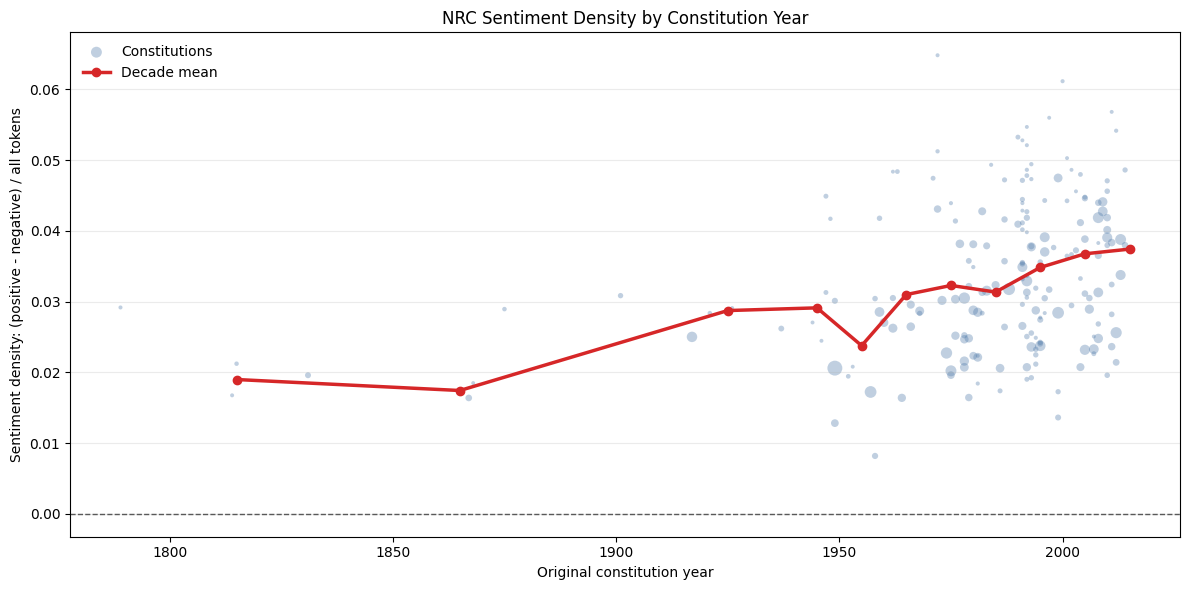

'iframe_figures/sentiment_by_original_year.png'

In [22]:
Path(figure_dir).mkdir(exist_ok=True)
fig_path = f"{figure_dir}/sentiment_by_original_year.png"

fig, ax = plt.subplots(figsize=(12, 6))
ax.axhline(0, color="0.35", linewidth=1, linestyle="--")
ax.scatter(
    plot_df["year"],
    plot_df["sentiment"],
    s=np.clip(plot_df["n_tokens"] / 900, 8, 120),
    alpha=0.35,
    color="#4c78a8",
    edgecolor="none",
    label="Constitutions",
)
ax.plot(
    decade_sent.index + 5,
    decade_sent["sentiment"],
    color="#d62728",
    linewidth=2.5,
    marker="o",
    label="Decade mean",
)
ax.set_title("NRC Sentiment Density by Constitution Year")
ax.set_xlabel("Original constitution year")
ax.set_ylabel("Sentiment density: (positive - negative) / all tokens")
ax.legend(frameon=False)
ax.grid(True, axis="y", alpha=0.25)
fig.tight_layout()
fig.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

fig_path

# Saveing Files and Plot

In [23]:
save_path = f"{output_dir}/{data_prefix}"
Path(output_dir).mkdir(exist_ok=True)

VOCAB_SENT.to_csv(f"{save_path}-VOCAB_SENT.csv", sep=CSV_DELIM)
BOW_SENT.to_csv(f"{save_path}-BOW_SENT-{bag}.csv", sep=CSV_DELIM)
DOC_SENT.to_csv(f"{save_path}-DOC_SENT-{bag}.csv", sep=CSV_DELIM)

{
    "VOCAB_SENT": f"{save_path}-VOCAB_SENT.csv",
    "BOW_SENT": f"{save_path}-BOW_SENT-{bag}.csv",
    "DOC_SENT": f"{save_path}-DOC_SENT-{bag}.csv",
    "plot": fig_path,
}

{'VOCAB_SENT': 'output/constitutions-VOCAB_SENT.csv',
 'BOW_SENT': 'output/constitutions-BOW_SENT-CONSTITUTIONS.csv',
 'DOC_SENT': 'output/constitutions-DOC_SENT-CONSTITUTIONS.csv',
 'plot': 'iframe_figures/sentiment_by_original_year.png'}